
The dataset is divided into training and testing sets to evaluate model performance on unseen data.

- Training Data → Used to train models  
- Testing Data → Used to evaluate performance  

This ensures that the model generalizes well and does not overfit.

<h2>1. Imports</h2>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

#---Preprocessing ----->
from sklearn.model_selection   import train_test_split, cross_val_score, StratifiedKFold 
from sklearn.preprocessing     import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFE

#----Models------->
from sklearn.linear_model   import LogisticRegression
from sklearn.svm            import SVC, LinearSVC
from sklearn.neighbors      import KNeighborsClassifier 
from sklearn.tree           import DecisionTreeClassifier, plot_tree
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes    import GaussianNB

#-------Evaluation ---------->
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import GridSearchCV

#-----Imbalance handling ------->
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print('imblearn not installed - SMOTE skipped. Install: pip install imbalanced-learn')

print('All imports done.')

All imports done.


<h2>2. Load Dataset</h2>

In [2]:
df = pd.read_csv('final_visualization.csv')
print('Shape:', df.shape)
df.head()

Shape: (45211, 21)


,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,y,was_previously_contacted,month_num,age_group,balance_tier
0,58.0,management,married,tertiary,no,2143,yes,no,unknown,5,...,261,1,0,0,unknown,no,0,5,50-59,High
1,44.0,technician,single,secondary,no,29,yes,no,unknown,5,...,151,1,0,0,unknown,no,0,5,40-49,Low
2,33.0,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,76,1,0,0,unknown,no,0,5,30-39,Low
3,47.0,blue-collar,married,secondary,no,1506,yes,no,unknown,5,...,92,1,0,0,unknown,no,0,5,40-49,Medium
4,33.0,blue-collar,single,secondary,no,1,no,no,unknown,5,...,198,1,0,0,unknown,no,0,5,30-39,Low


In [3]:
print('\n Data Types')
print(df.dtypes)

print('\n Missing Values..')
print(df.isnull().sum())


 Data Types
age                         float64
job                          object
marital                      object
education                    object
default                      object
balance                       int64
housing                      object
loan                         object
contact                      object
day                           int64
month                        object
duration                      int64
campaign                      int64
pdays                         int64
previous                      int64
poutcome                     object
y                            object
was_previously_contacted      int64
month_num                     int64
age_group                    object
balance_tier                 object
dtype: object

 Missing Values..
age                         0
job                         0
marital                     0
education                   0
default                     0
balance                     0
housing           

In [4]:
print('\nClass Balance(%):')
print(df['y'].value_counts(normalize=True)*100)


Class Balance(%):
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


<h2>3. Feature Selection</h2>
<h3>3a. Drop Redundant / Derived Columns</h3>
<p>1. duration   -> Data leakage - known only after call ends</p>
<p>2. month      -> Replaced by month_num (numeric, sortable)</p>
<p>3. age_group  -> Binned version of age - redundant</p>
<p>4. balance_tier -> Binned version of balance - redundant</p>
<p>5. balance, campaign, previous, pdays -> summarised versions kept instead</p>

In [5]:
drop_cols = [
    'duration',
    'month',
    'age_group',
    'balance_tier',
    'balance',
    'campaign',
    'previous',
    'pdays'
]
df_model = df.drop(columns=drop_cols)
print('Shape after dropping redundant columns:', df_model.shape)
print('\nRemaining columns:') 
print(df_model.columns.tolist())

Shape after dropping redundant columns: (45211, 13)

Remaining columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day', 'poutcome', 'y', 'was_previously_contacted', 'month_num']


<h2>4. Encoding</h2>
<p>1. Binary (yes/no) columns: default, housing, loan -> Label Encoding</p>
<p>2. Target y -> Label Encoding (yes=1, no=0)</p>
<p>3. Nominal columns: job, marital, education, contact, poutcome -> One-Hot Encoding</p>

In [6]:
df_enc = df_model.copy()

binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    df_enc[col] = df_enc[col].map({'yes': 1, 'no': 0})
print('Binary encoding done:', binary_cols)

df_enc['y'] = df_enc['y'].map({'yes': 1, 'no': 0})
print('Target y encoded: no=0, yes=1') 
print('Class distribution after encoding:') 
print(df_enc['y'].value_counts())

ohe_cols = ['job', 'marital', 'education', 'contact', 'poutcome']
df_enc = pd.get_dummies(df_enc, columns=ohe_cols, drop_first=True, dtype=int)
print(f'\nShape after One-Hot Encoding: {df_enc.shape}') 
print('Null check:', df_enc.isnull().sum().sum(), 'nulls') 
df_enc.head(3)

Binary encoding done: ['default', 'housing', 'loan']
Target y encoded: no=0, yes=1
Class distribution after encoding:
y
0    39922
1     5289
Name: count, dtype: int64



Shape after One-Hot Encoding: (45211, 27)
Null check: 0 nulls


,age,default,housing,loan,day,y,was_previously_contacted,month_num,job_blue-collar,job_entrepreneur,...,job_unemployed,marital_married,marital_single,education_secondary,education_tertiary,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,58.0,0,1,0,5,0,0,5,0,0,...,0,1,0,0,1,0,1,0,0,1
1,44.0,0,1,0,5,0,0,5,0,0,...,0,0,1,1,0,0,1,0,0,1
2,33.0,0,1,1,5,0,0,5,0,1,...,0,1,0,1,0,0,1,0,0,1


<h2>5. Define Feature (X) and Target (y)</h2>

In [7]:
X = df_enc.drop(columns=['y'])
y = df_enc['y']

print('Feature matrix X:', X.shape)
print('Target vector y:', y.shape)
print('\nClass balance:') 
print(y.value_counts())
print(f' -> Imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1 (no:yes)')

Feature matrix X: (45211, 26)
Target vector y: (45211,)

Class balance:
y
0    39922
1     5289
Name: count, dtype: int64
 -> Imbalance ratio: 7.5:1 (no:yes)


<h2>5a. SelectKBest - Statistical Feature Scores</h2>
<p>Using ANOVA F-score (f_classif) to rank features by their statistical relationship with the target.</p>

Top 15 features by F-score:
                 Feature     F_Score       P_Value
        poutcome_success 4697.113837  0.000000e+00
was_previously_contacted 1301.219109 6.086689e-281
        poutcome_unknown 1297.815887 3.186284e-280
         contact_unknown 1053.932776 1.456834e-228
                 housing  892.950576 2.621927e-194
             job_retired  285.698413  6.767486e-64
             job_student  268.917823  2.917711e-60
         job_blue-collar  230.863951  5.195184e-52
                    loan  211.167395  9.793658e-48
      education_tertiary  200.499806  2.032274e-45
          marital_single  183.181227  1.180612e-41
         marital_married  164.766391  1.197208e-37
          job_management   49.043706  2.538079e-12
          poutcome_other   46.211124  1.074872e-11
     education_secondary   45.701836  1.393619e-11


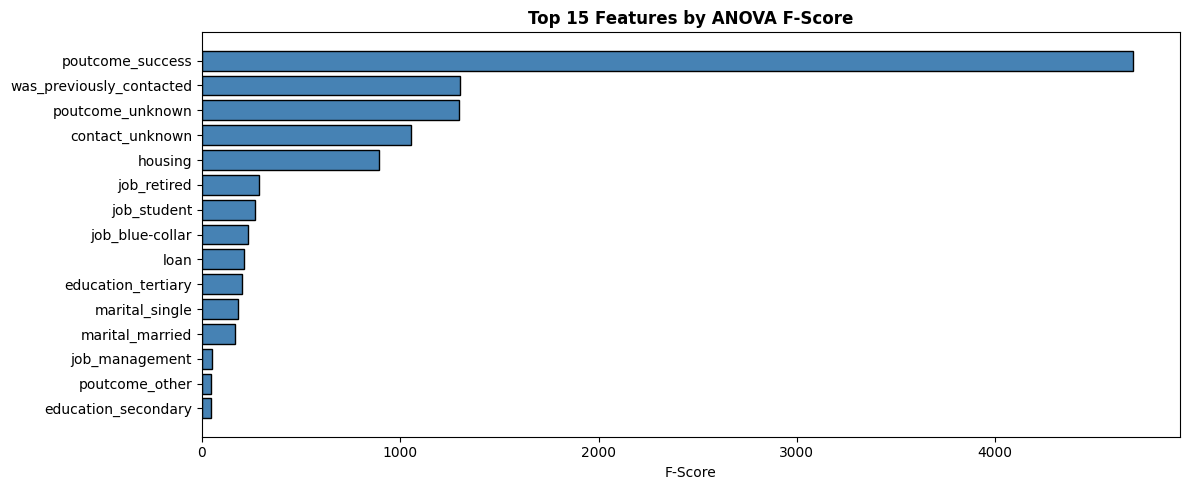

In [8]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feat_scores = pd.DataFrame({
    'Feature': X.columns,
    'F_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values('F_Score', ascending=False)

print('Top 15 features by F-score:')
print(feat_scores.head(15).to_string(index=False))

plt.figure(figsize=(12, 5))
top15 = feat_scores.head(15)
plt.barh(top15['Feature'][::-1], top15['F_Score'][::-1], color='steelblue', edgecolor='black')
plt.xlabel('F-Score')
plt.title('Top 15 Features by ANOVA F-Score', fontweight='bold')
plt.tight_layout()
plt.show()

<h2>6. Feature Scaling</h2>
<h4>StandardScaler</h4>

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}') 
print(f'Train Class balance: {y_train.value_counts().to_dict()}')
print(f'Test class balance: {y_test.value_counts().to_dict()}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('StandardScaler applied.')
print(f'Train mean (first 3 cols): {X_train_scaled[:,:3].mean(axis=0).round(4)}')
print(f'Train std (first 3 cols): {X_train_scaled[:,:3].std(axis=0).round(4)}')

Train: (36168, 26) | Test: (9043, 26)
Train Class balance: {0: 31937, 1: 4231}
Test class balance: {0: 7985, 1: 1058}
StandardScaler applied.
Train mean (first 3 cols): [0. 0. 0.]
Train std (first 3 cols): [1. 1. 1.]


<h2>7. Handle Class Imbalance with SMOTE</h2>
<p>Our dataset is 88% no, 12% yes - SMOTE generates synthetic minority samples.</p>
<p>Apply SMOTE <b>only on training data</b>, never on test data.</p>

In [10]:
if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)
    print('After SMOTE:')
    print(pd.Series(y_train_res).value_counts())
    print(f'Resampled shape: {X_train_res.shape}')
else:
    X_train_res, y_train_res = X_train_scaled, y_train
    print('SMOTE not available. Using class_weight="balanced" in models instead.')

After SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64
Resampled shape: (63874, 26)


<h2>8. Model Fitting</h2>

<h3>8a. Logistic Regression</h3>

Logistic Regression is used as a baseline model for binary classification.

- Simple and interpretable  
- Works well for linearly separable data  
- Provides probability estimates  

In [11]:
model = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_res, y_train_res)
print('Logistic Regression trained.')

Logistic Regression trained.


<h2>8a1. Evaluation</h2>

In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

acc_lr   = accuracy_score(y_test, y_pred)
y_pred_lr = y_pred.copy()
cv_lr    = cross_val_score(model, X_train_res, y_train_res, cv=3, scoring='roc_auc').mean()

print('== Classification Report ==')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

== Classification Report ==
              precision    recall  f1-score   support

          No       0.94      0.68      0.79      7985
         Yes       0.22      0.67      0.33      1058

    accuracy                           0.68      9043
   macro avg       0.58      0.67      0.56      9043
weighted avg       0.85      0.68      0.74      9043

ROC-AUC Score: 0.7441


<p>Confusion Matrix</p>

In [13]:
print('The accuracy :', acc_lr)

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

print('Precision:', precision_score(y_test, y_pred))
print('Recall:',    recall_score(y_test, y_pred))
print('F1 Score:',  f1_score(y_test, y_pred))

The accuracy : 0.6815216189317704
Confusion Matrix:
 [[5458 2527]
 [ 353  705]]
Precision: 0.21813118811881188
Recall: 0.666351606805293
F1 Score: 0.32867132867132864


The curve shows the trade-off between sensitivity and specificity.

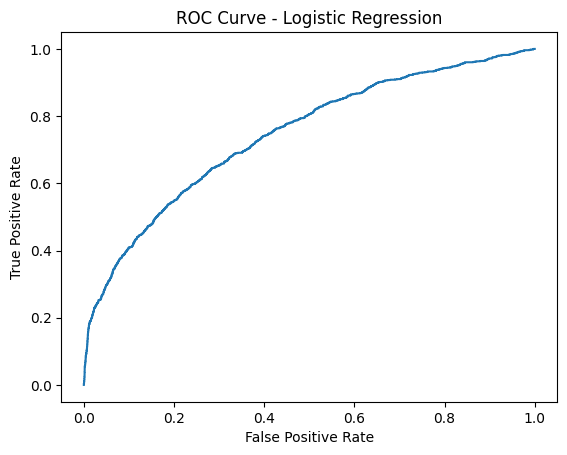

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.show()

<h2>8b. KNN (K-Nearest Neighbors)</h2>

KNN is a distance-based algorithm that classifies data points based on their nearest neighbors.

- Works well with smaller datasets  
- Performance depends on the value of K  

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_res, y_train_res)

y_pred = knn.predict(X_test_scaled)
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

acc_knn   = accuracy_score(y_test, y_pred)
y_pred_knn = y_pred.copy()
cv_knn    = cross_val_score(knn, X_train_res, y_train_res, cv=3, scoring='roc_auc').mean()

print('=== KNN Results ===')
print(f'Accuracy: {acc_knn:.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

=== KNN Results ===
Accuracy: 0.7439
ROC-AUC:  0.6798

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.77      0.84      7985
         Yes       0.23      0.52      0.32      1058

    accuracy                           0.74      9043
   macro avg       0.58      0.65      0.58      9043
weighted avg       0.84      0.74      0.78      9043



In [16]:
cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)


Confusion Matrix:
[[6177 1808]
 [ 508  550]]


In [17]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_res, y_train_res)
print('Best Parameters:', grid.best_params_)
print('Best Score:', round(grid.best_score_, 4))

Best Parameters: {'n_neighbors': 3, 'weights': 'distance'}
Best Score: 0.8585


ROC-AUC Score: 0.6798


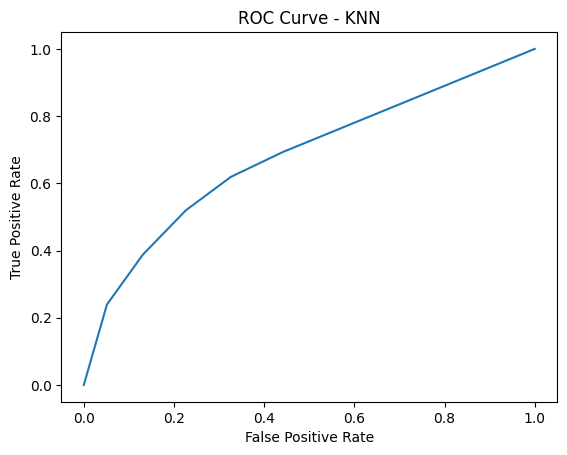

In [18]:
y_prob = knn.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC Score: {auc:.4f}')

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.show()

<h2>Support Vector Machine (SVM)</h2>

SVM finds the optimal boundary between classes.

- Effective in high-dimensional spaces  
- Can handle linear and non-linear data  
- LinearSVC used for speed on large datasets  

In [19]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
print('Training SVM...')
svm_model.fit(X_train_res, y_train_res)
print('SVM trained.')

Training SVM...
SVM trained.


In [ ]:
y_pred    = svm_model.predict(X_test_scaled)
y_scores  = svm_model.decision_function(X_test_scaled)

acc_svm   = accuracy_score(y_test, y_pred)
y_pred_svm = y_pred.copy()
cv_svm    = cross_val_score(svm_model, X_train_res, y_train_res, cv=3, scoring='roc_auc').mean()

print('=== Linear SVM Results ===')
print(f'Accuracy: {acc_svm:.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, y_scores):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

=== Linear SVM Results ===
Accuracy: 0.6806
ROC-AUC:  0.7442

Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.68      0.79      7985
         Yes       0.22      0.67      0.33      1058

    accuracy                           0.68      9043
   macro avg       0.58      0.68      0.56      9043
weighted avg       0.86      0.68      0.74      9043



In [21]:
cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)


Confusion Matrix:
[[5445 2540]
 [ 348  710]]


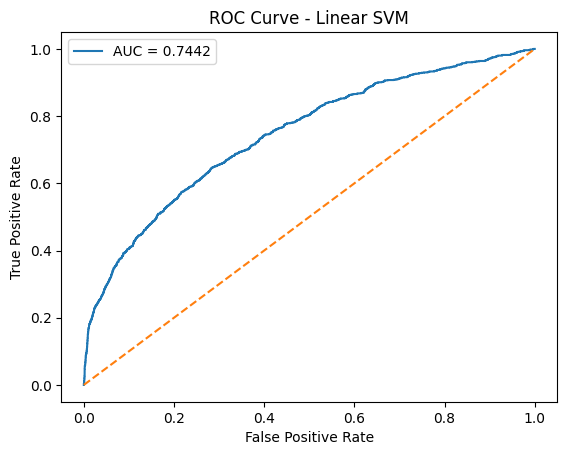

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Linear SVM')
plt.legend()
plt.show()

<h2>DECISION TREE</h2>

Decision Tree splits the dataset based on feature thresholds forming a tree structure.

- Easy to understand and interpret  
- Handles both numerical and categorical data  
- Prone to overfitting if not controlled  
- Depth tuned via AUC sweep  

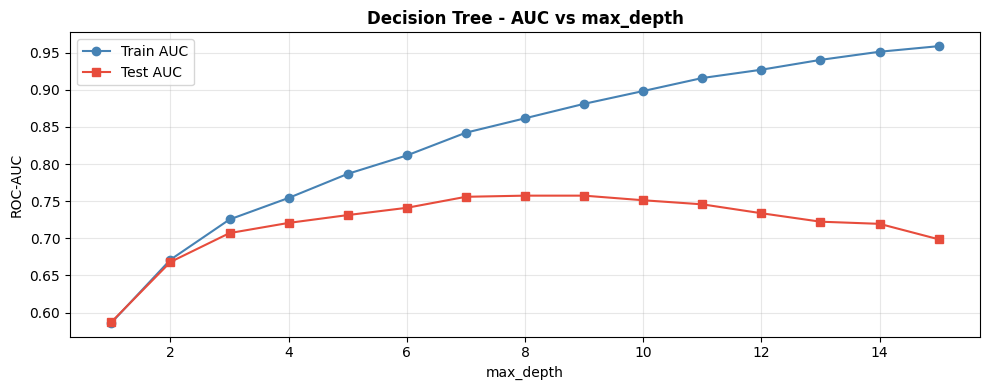

Best max_depth = 9 with test AUC = 0.7574


In [23]:
depth_range = range(1, 16)
train_auc_list, test_auc_list = [], []

for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    dt.fit(X_train_res, y_train_res)
    train_auc_list.append(roc_auc_score(y_train_res, dt.predict_proba(X_train_res)[:,1]))
    test_auc_list.append(roc_auc_score(y_test,       dt.predict_proba(X_test_scaled)[:,1]))

plt.figure(figsize=(10, 4))
plt.plot(depth_range, train_auc_list, 'o-', label='Train AUC', color='steelblue')
plt.plot(depth_range, test_auc_list,  's-', label='Test AUC',  color='#e74c3c')
plt.xlabel('max_depth')
plt.ylabel('ROC-AUC')
plt.title('Decision Tree - AUC vs max_depth', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best_depth = depth_range[test_auc_list.index(max(test_auc_list))]
print(f'Best max_depth = {best_depth} with test AUC = {max(test_auc_list):.4f}')

In [24]:
model = DecisionTreeClassifier(
    max_depth=best_depth,
    criterion='gini',
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_res, y_train_res)
print('Decision Tree trained.')

Decision Tree trained.


In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

acc_dt   = accuracy_score(y_test, y_pred)
y_pred_dt = y_pred.copy()
cv_dt    = cross_val_score(model, X_train_res, y_train_res, cv=3, scoring='roc_auc').mean()

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

          No       0.93      0.93      0.93      7985
         Yes       0.48      0.47      0.48      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.88      0.88      0.88      9043

ROC-AUC Score: 0.7643


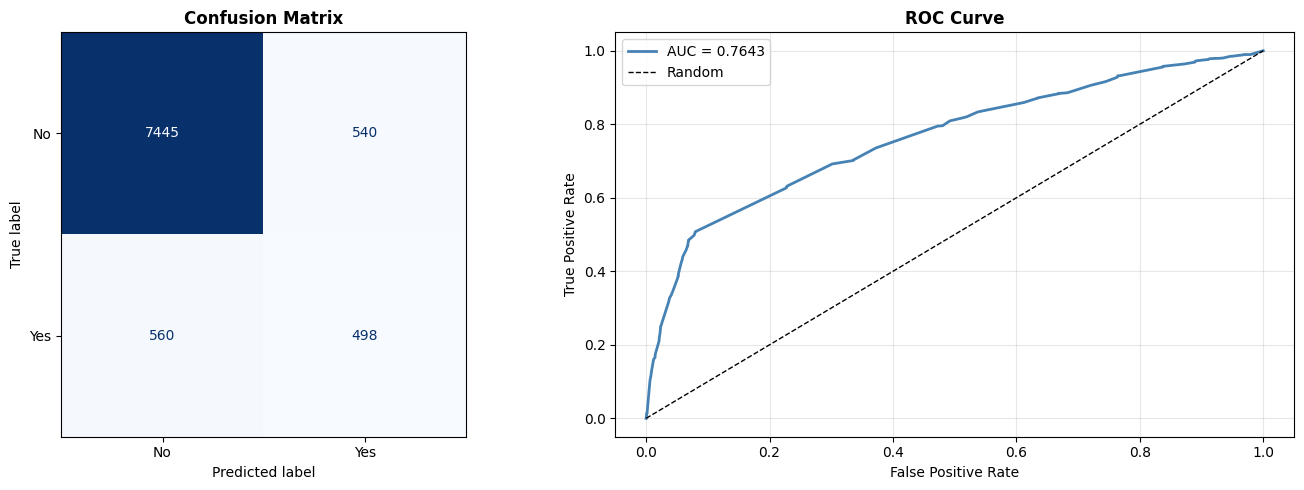

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No','Yes']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_title('ROC Curve', fontweight='bold')

plt.tight_layout(); plt.show()

In [27]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=skf, scoring='roc_auc')
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Per-fold scores: {np.round(cv_scores, 4)}')

5-Fold CV ROC-AUC: 0.8736 +/- 0.0036
Per-fold scores: [0.8797 0.8745 0.8703 0.8696 0.8739]


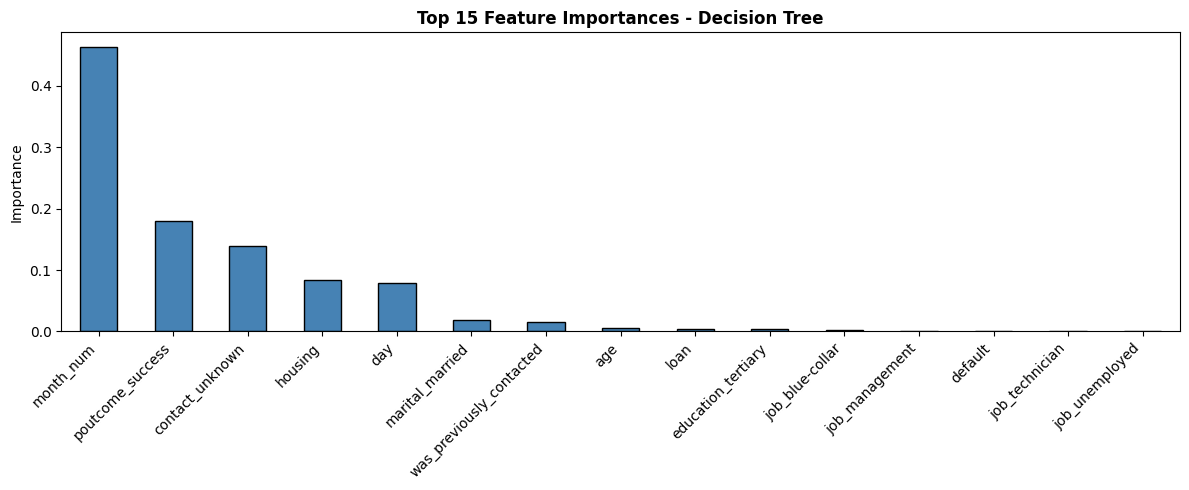

In [28]:
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
imp.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances - Decision Tree', fontweight='bold')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [29]:
print('Decision Tree Test Accuracy:', acc_dt)

Decision Tree Test Accuracy: 0.878358951675329


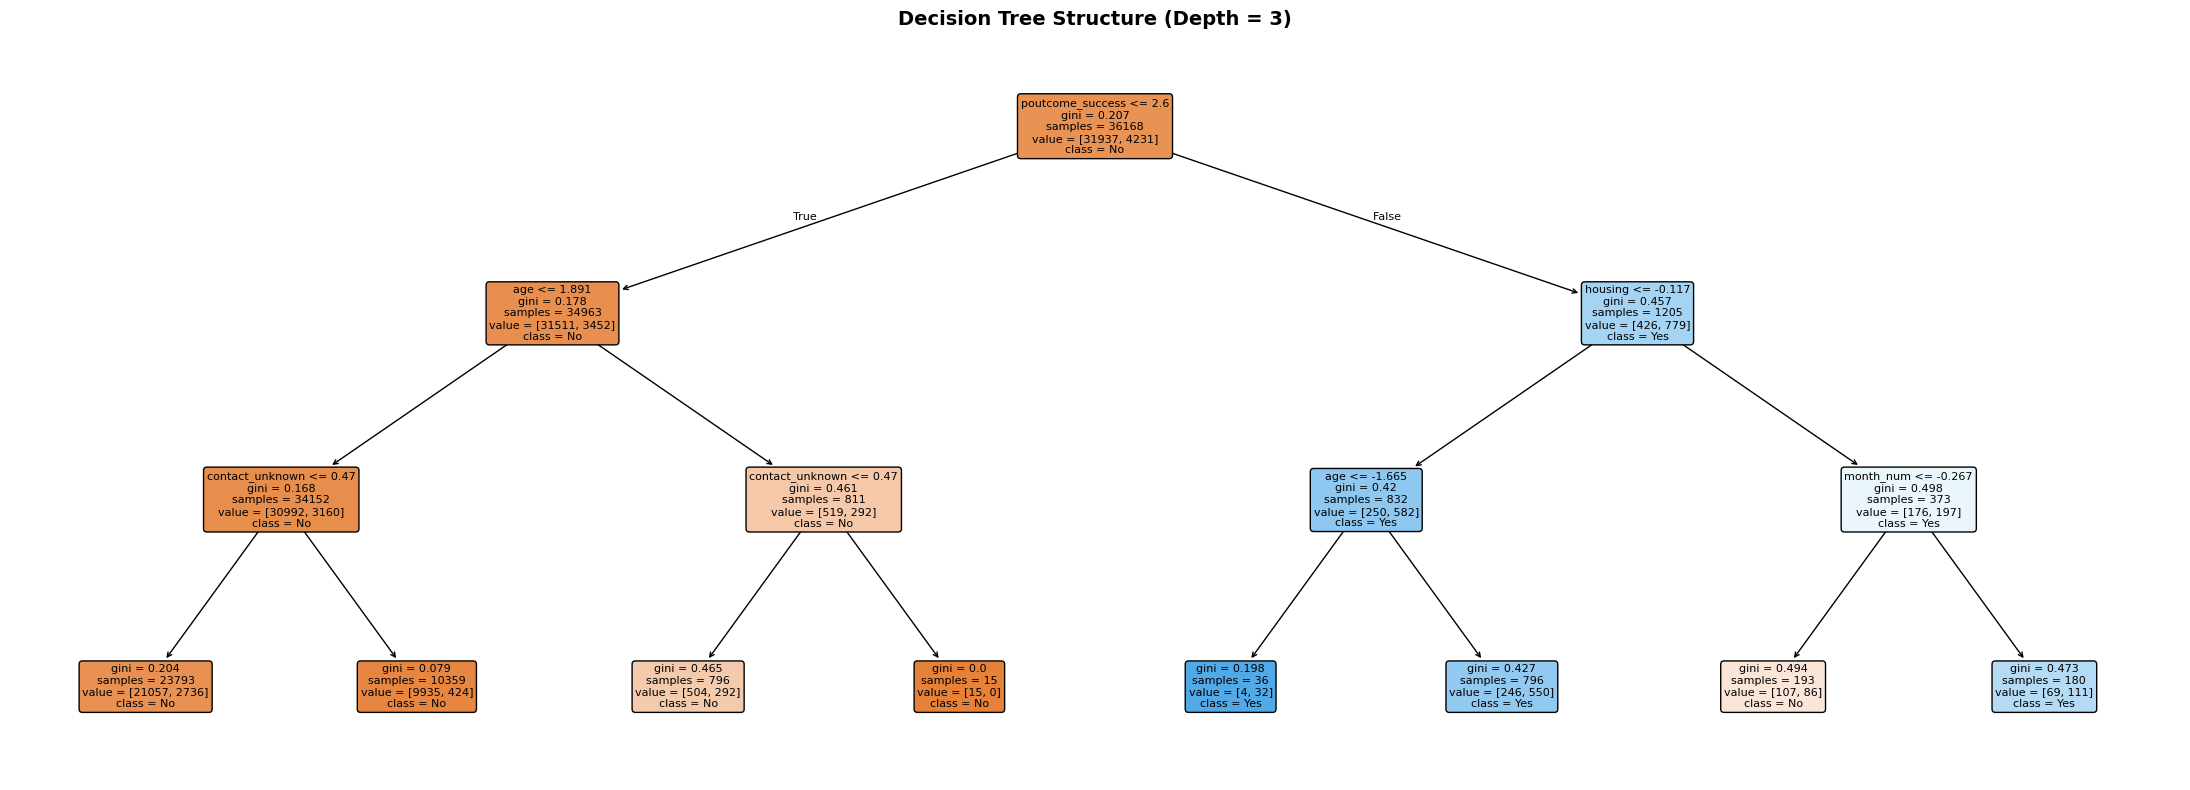

In [ ]:
dt_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_vis.fit(X_train_scaled, y_train)

feature_names = X_train.columns.tolist()
class_names   = ['No', 'Yes']

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_vis,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree Structure (Depth = 3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<h2>RANDOM FOREST</h2>

Random Forest is an ensemble of decision trees that reduces overfitting via bagging.

- Reduces overfitting compared to a single Decision Tree  
- Works well on large datasets  
- Provides feature importance  

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)
print('Random Forest trained with 100 trees.')

Random Forest trained with 100 trees.


In [ ]:
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

acc_rf   = accuracy_score(y_test, y_pred)
y_pred_rf = y_pred.copy()
cv_rf    = cross_val_score(rf_model, X_train_res, y_train_res, cv=3, scoring='roc_auc').mean()

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

          No       0.94      0.91      0.92      7985
         Yes       0.44      0.53      0.48      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.72      0.70      9043
weighted avg       0.88      0.87      0.87      9043

ROC-AUC Score: 0.7892


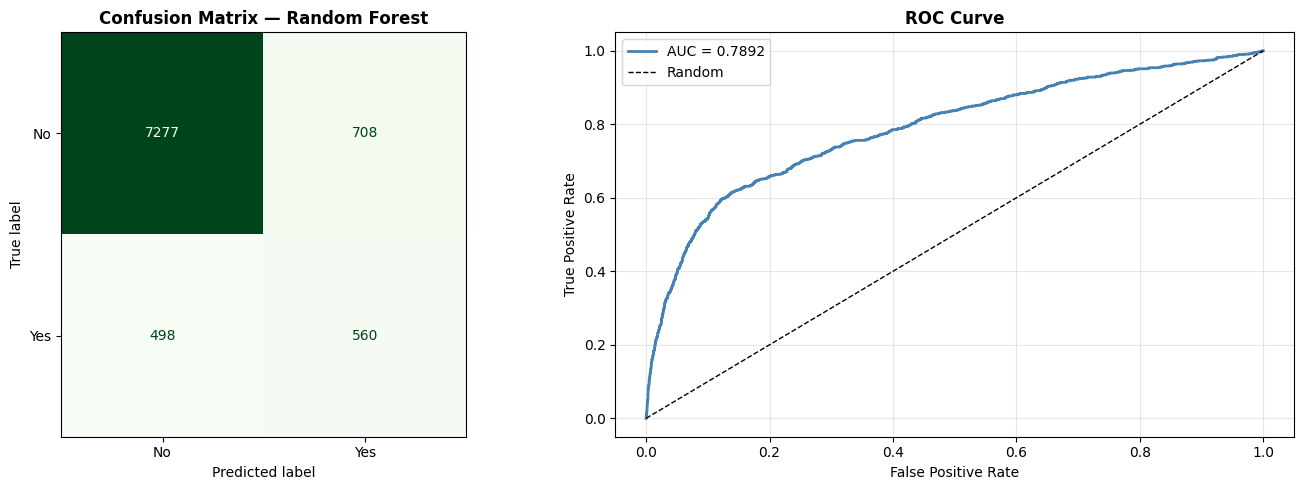

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No','Yes']).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix — Random Forest', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_title('ROC Curve', fontweight='bold')

plt.tight_layout(); plt.show()

In [34]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train_res, y_train_res, cv=skf, scoring='roc_auc')
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Per-fold scores: {np.round(cv_scores, 4)}')

5-Fold CV ROC-AUC: 0.9504 +/- 0.0015
Per-fold scores: [0.9524 0.9483 0.9516 0.9491 0.9504]


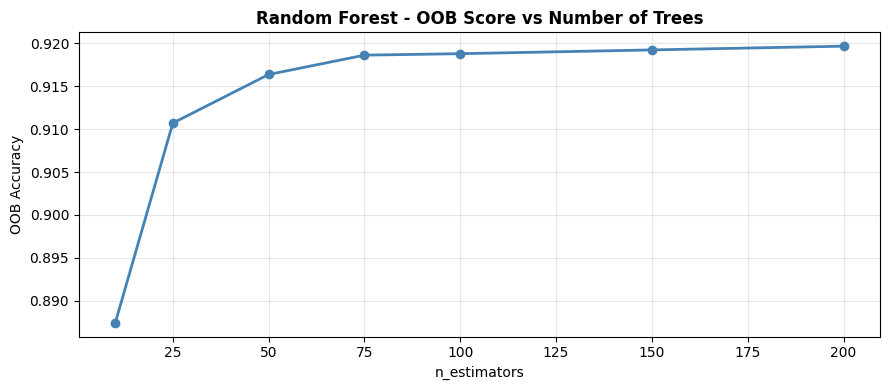

 n_estimators  OOB_Score
           10   0.887435
           25   0.910715
           50   0.916382
           75   0.918637
          100   0.918809
          150   0.919247
          200   0.919686


In [35]:
rf_oob = RandomForestClassifier(
    max_features='sqrt', class_weight='balanced',
    oob_score=True, random_state=42, n_jobs=-1
)
oob_scores = []
for n in [10, 25, 50, 75, 100, 150, 200]:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_train_res, y_train_res)
    oob_scores.append((n, rf_oob.oob_score_))

oob_df = pd.DataFrame(oob_scores, columns=['n_estimators', 'OOB_Score'])
plt.figure(figsize=(9, 4))
plt.plot(oob_df['n_estimators'], oob_df['OOB_Score'], 'o-', color='steelblue', lw=2)
plt.xlabel('n_estimators'); plt.ylabel('OOB Accuracy')
plt.title('Random Forest - OOB Score vs Number of Trees', fontweight='bold')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(oob_df.to_string(index=False))

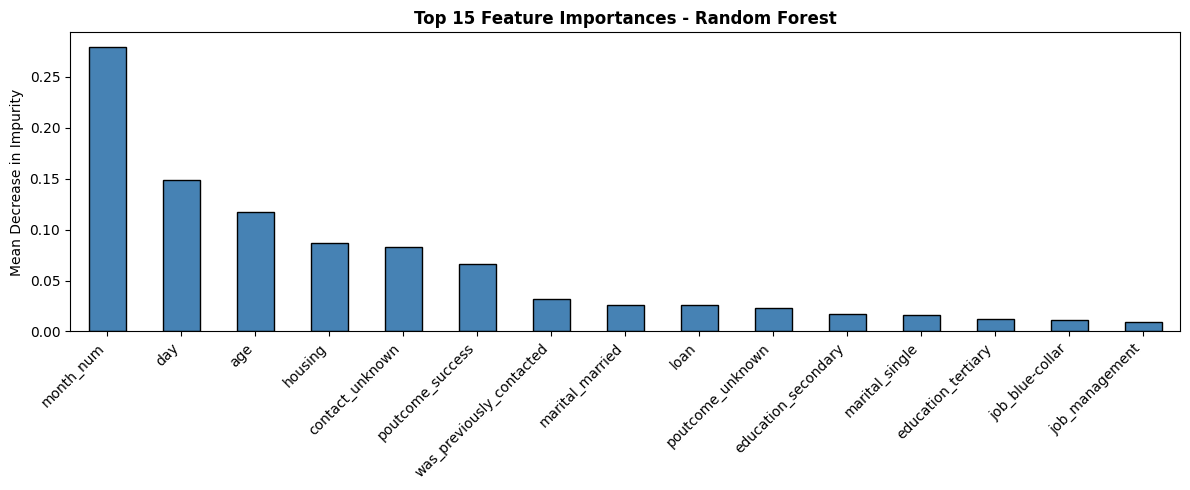

Top 10 features:
month_num                   0.279397
day                         0.148700
age                         0.117447
housing                     0.087218
contact_unknown             0.083060
poutcome_success            0.066020
was_previously_contacted    0.031710
marital_married             0.026421
loan                        0.025720
poutcome_unknown            0.023119
dtype: float64


In [36]:
imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
imp.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances - Random Forest', fontweight='bold')
plt.ylabel('Mean Decrease in Impurity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 features:')
print(imp.head(10))

In [37]:
print('Random Forest Test Accuracy:', acc_rf)

Random Forest Test Accuracy: 0.8666371779276789


<h2>NAIVE BAYES</h2>

Naive Bayes is a probabilistic classifier based on Bayes' theorem.

- Assumes feature independence  
- Very fast and efficient  
- Works well with large datasets  

In [38]:
nb_model = GaussianNB(var_smoothing=1e-9)
nb_model.fit(X_train_res, y_train_res)
print('Naive Bayes trained.')

Naive Bayes trained.


In [ ]:
y_pred = nb_model.predict(X_test_scaled)
y_prob = nb_model.predict_proba(X_test_scaled)[:, 1]

acc_nb   = accuracy_score(y_test, y_pred)
y_pred_nb = y_pred.copy()
cv_nb    = cross_val_score(nb_model, X_train_res, y_train_res, cv=3, scoring='roc_auc').mean()

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No','Yes']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

          No       0.92      0.79      0.85      7985
         Yes       0.24      0.51      0.33      1058

    accuracy                           0.76      9043
   macro avg       0.58      0.65      0.59      9043
weighted avg       0.84      0.76      0.79      9043

ROC-AUC Score: 0.7171


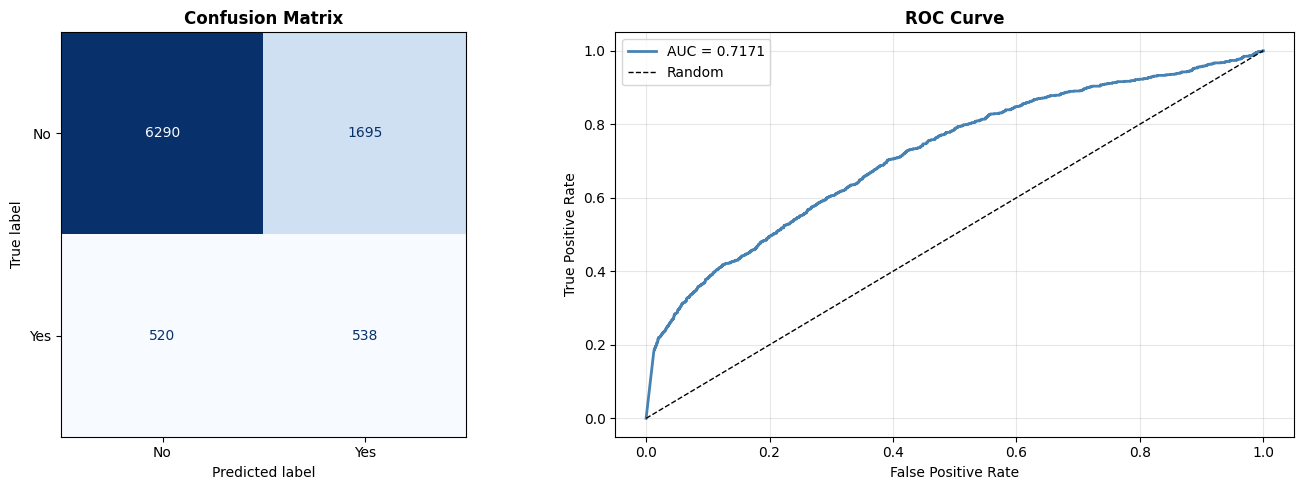

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No','Yes']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_title('ROC Curve', fontweight='bold')

plt.tight_layout(); plt.show()

In [41]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(nb_model, X_train_res, y_train_res, cv=skf, scoring='roc_auc')
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Per-fold scores: {np.round(cv_scores, 4)}')

5-Fold CV ROC-AUC: 0.7095 +/- 0.0050
Per-fold scores: [0.7107 0.7006 0.7081 0.715  0.7129]


var_smoothing=1e-12 | AUC=0.7171
var_smoothing=1e-09 | AUC=0.7171
var_smoothing=1e-06 | AUC=0.7171
var_smoothing=1e-03 | AUC=0.7171
var_smoothing=1e-01 | AUC=0.7170


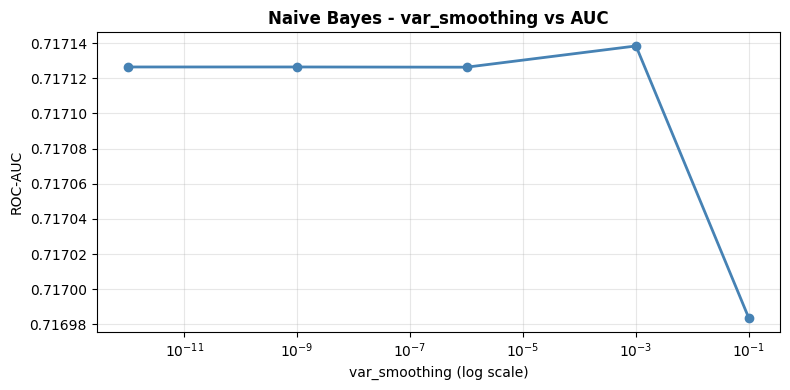

In [42]:
smooth_vals = [1e-12, 1e-9, 1e-6, 1e-3, 1e-1]
auc_vals = []

for s in smooth_vals:
    nb = GaussianNB(var_smoothing=s)
    nb.fit(X_train_res, y_train_res)
    auc = roc_auc_score(y_test, nb.predict_proba(X_test_scaled)[:,1])
    auc_vals.append(auc)
    print(f'var_smoothing={s:.0e} | AUC={auc:.4f}')

plt.figure(figsize=(8, 4))
plt.semilogx(smooth_vals, auc_vals, 'o-', color='steelblue', lw=2)
plt.xlabel('var_smoothing (log scale)'); plt.ylabel('ROC-AUC')
plt.title('Naive Bayes - var_smoothing vs AUC', fontweight='bold')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [43]:
print('Naive Bayes Test Accuracy:', acc_nb)

prior_df = pd.DataFrame({
    'Class': ['No (0)', 'Yes (1)'],
    'Prior Probability': nb_model.class_prior_
})
print('Class Prior Probabilities (learned from training):')
print(prior_df.to_string(index=False))

mean_df = pd.DataFrame(nb_model.theta_, columns=X.columns, index=['No','Yes']).T
print('\nTop 10 feature means per class:')
print(mean_df.head(10))

Naive Bayes Test Accuracy: 0.7550591617825942
Class Prior Probabilities (learned from training):
  Class  Prior Probability
 No (0)                0.5
Yes (1)                0.5

Top 10 feature means per class:
                                No       Yes
age                      -0.006702  0.036486
default                   0.008903 -0.062911
housing                   0.050750 -0.390858
loan                      0.024213 -0.214644
day                       0.009680 -0.087427
was_previously_contacted -0.059543  0.454993
month_num                -0.006549  0.047412
job_blue-collar           0.025904 -0.193068
job_entrepreneur          0.006635 -0.056664
job_housemaid             0.006358 -0.048486


<h2>9. Final Results Summary — All Models</h2>

Results are collected from the individually trained models above.
No retraining — each model is evaluated exactly as seen in its own section.

In [44]:
summary_data = [
    ('Logistic Regression',          acc_lr,  cv_lr,  y_pred_lr),
    ('KNN (k=5)',                     acc_knn, cv_knn, y_pred_knn),
    ('SVM (Linear)',                  acc_svm, cv_svm, y_pred_svm),
    (f'Decision Tree (depth={best_depth})', acc_dt,  cv_dt,  y_pred_dt),
    ('Random Forest (100 trees)',     acc_rf,  cv_rf,  y_pred_rf),
    ('Naive Bayes',                   acc_nb,  cv_nb,  y_pred_nb),
]

rows = []
for name, acc, cv, yp in summary_data:
    rows.append({
        'Model':         name,
        'Test Accuracy': f'{acc:.4f}',
        'CV ROC-AUC':    f'{cv:.4f}',
        'Macro F1':      f"{f1_score(y_test, yp, average='macro', zero_division=0):.4f}"
    })

summary = pd.DataFrame(rows)

print('=' * 65)
print('   FINAL RESULTS SUMMARY - ALL MODELS')
print('=' * 65)
print(summary.to_string(index=False))
print('=' * 65)

best_idx = summary['Test Accuracy'].astype(float).idxmax()
best_row = summary.loc[best_idx]
print(f"\nBest Model (by Test Accuracy) : {best_row['Model']}")
print(f"  Test Accuracy = {float(best_row['Test Accuracy'])*100:.2f}%")
print(f"  CV ROC-AUC   = {best_row['CV ROC-AUC']}")
print(f"  Macro F1     = {best_row['Macro F1']}")

   FINAL RESULTS SUMMARY - ALL MODELS
                    Model Test Accuracy CV ROC-AUC Macro F1
      Logistic Regression        0.6815     0.7427   0.5600
                KNN (k=5)        0.7439     0.9007   0.5821
             SVM (Linear)        0.6806     0.7426   0.5600
  Decision Tree (depth=9)        0.8784     0.8709   0.7032
Random Forest (100 trees)        0.8666     0.9472   0.7025
              Naive Bayes        0.7551     0.7094   0.5886

Best Model (by Test Accuracy) : Decision Tree (depth=9)
  Test Accuracy = 87.84%
  CV ROC-AUC   = 0.8709
  Macro F1     = 0.7032


<h2>10. Model Accuracy Comparison - Bar Chart</h2>

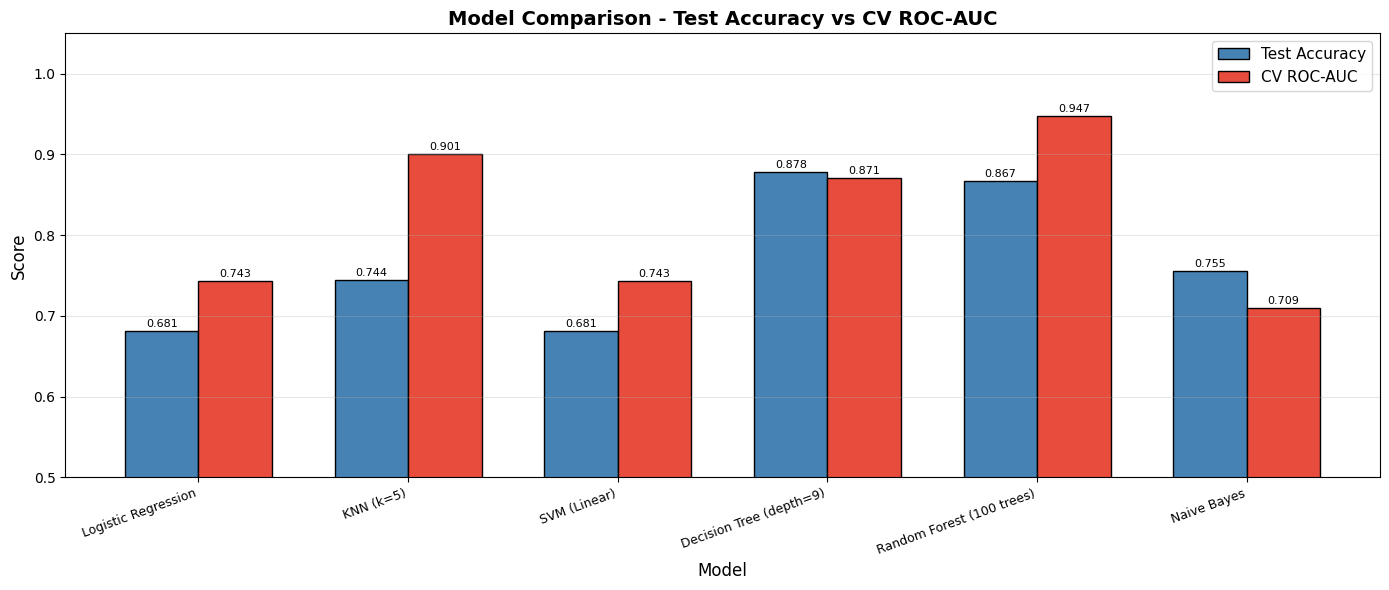

In [45]:
model_names = summary['Model'].tolist()
test_accs   = summary['Test Accuracy'].astype(float).tolist()
cv_aucs     = summary['CV ROC-AUC'].astype(float).tolist()

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, cv_aucs,   width, label='CV ROC-AUC',    color='#e74c3c',  edgecolor='black')

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison - Test Accuracy vs CV ROC-AUC', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()